# Building an image recognition neural network

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras

# Setting random seeds to get reproducible results
np.random.seed(0)
import tensorflow as tf
tf.random.set_seed(1)

/Users/khanhlinhpham/Documents/manning/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### Importing and reading the dataset

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data() #the MNIST dataset and already splits it into training and testing sets
print("Size of the training set", len(x_train))
print("Size of the testing set", len(x_test))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Size of the training set 60000
Size of the testing set 10000


The label is 2


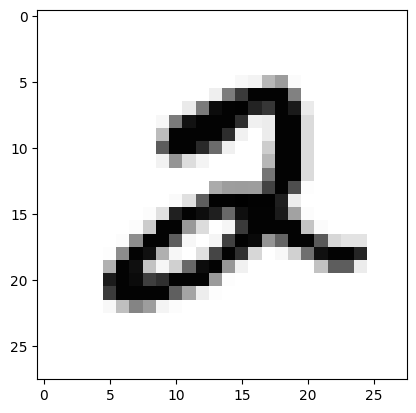

In [3]:
plt.imshow(x_train[5], cmap='Greys')
print("The label is", y_train[5])

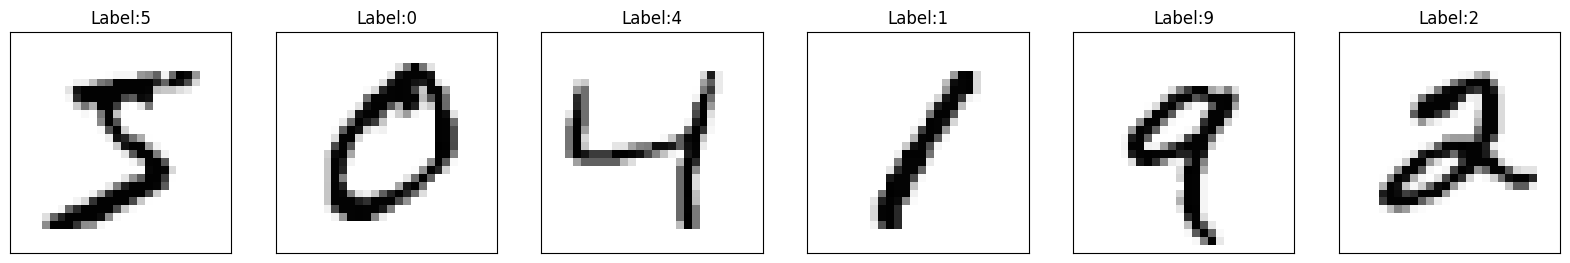

In [5]:
fig = plt.figure(figsize=(20,20))
for i in range(6):
    ax = fig.add_subplot(1, 6, i+1, xticks=[], yticks=[])
    ax.imshow(x_train[i], cmap='Greys')
    ax.set_title('Label:' + str(y_train[i]))

### Pre-processing the data

In [8]:
# Reshaping the features.
# In the reshape function we use the -1 as a placeholder for the size of the dataset.

x_train_reshaped = x_train.reshape(-1, 28*28) #each image = 28 rows × 28 columns (value of 0s)
x_test_reshaped = x_test.reshape(-1, 28*28)
x_train_reshaped

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [14]:
from tensorflow.keras.utils import to_categorical
y_train_cat = to_categorical(y_train, 10) #has been one-hot encoded and y_train contains labels like 0, 1, 2, 3, ..., 9
y_test_cat = to_categorical(y_test, 10)
y_train_cat[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

### Building and training the neural network

In [15]:
# Imports
#import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
#from tensorflow.keras.layers import Dense, Dropout, Activation
#from tensorflow.keras.optimizers import SGD

# Building the model
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(28*28,)))
model.add(Dropout(.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(.2))
model.add(Dense(10, activation='softmax'))

# Compiling the model
model.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.fit(x_train_reshaped, y_train_cat, epochs=10, batch_size=10)

Epoch 1/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 4s 518us/step - accuracy: 0.6251 - loss: 5.0545
Epoch 2/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 3s 538us/step - accuracy: 0.8468 - loss: 0.5697
Epoch 3/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 3s 529us/step - accuracy: 0.8839 - loss: 0.4396
Epoch 4/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 3s 542us/step - accuracy: 0.8992 - loss: 0.3945
Epoch 5/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 3s 533us/step - accuracy: 0.9065 - loss: 0.3599
Epoch 6/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 3s 513us/step - accuracy: 0.9088 - loss: 0.3587
Epoch 7/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 3s 520us/step - accuracy: 0.9117 - loss: 0.3387
Epoch 8/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 3s 512us/step - accuracy: 0.9183 - loss: 0.3289
Epoch 9/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 3s 519us/step - accuracy: 0.9202 - loss: 0.3291
Epoch 10/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 4s 597us/step - accuracy: 0.9252 - loss: 0.3034


### Making predictions

In [16]:
predictions_vector = model.predict(x_test_reshaped)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 359us/step


In [17]:
predictions = [np.argmax(pred) for pred in predictions_vector]

The label is 4
The prediction is 8


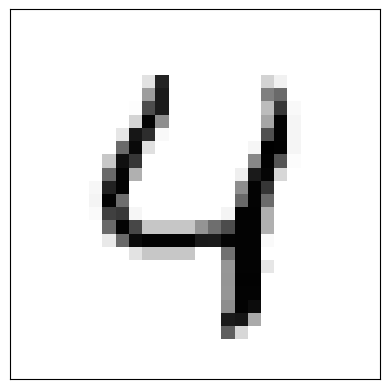

In [18]:
plt.imshow(x_test[4], cmap='Greys')
plt.xticks([])
plt.yticks([])
print("The label is", y_test[4])
print("The prediction is", predictions[4])

Sometimes the model makes mistakes too.

The label is 3
The prediction is 0


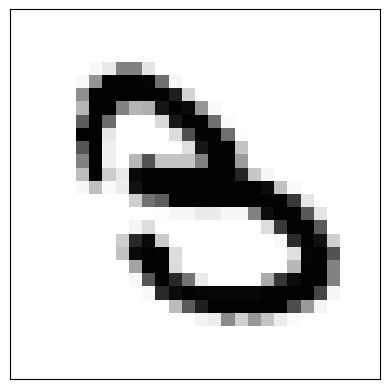

In [19]:
plt.imshow(x_test[18], cmap='Greys')
plt.xticks([])
plt.yticks([])
print("The label is", y_test[18])
print("The prediction is", predictions[18])

### Finding the accuracy of the model on the test set

In [20]:
num_correct = 0
for i in range(len(predictions)):
    if predictions[i] == y_test[i]:
        num_correct += 1

print("The model is correct", num_correct, "times out of", len(y_test))
print("The accuracy is", num_correct/len(y_test))

The model is correct 1141 times out of 10000
The accuracy is 0.1141
